1. DATA LOADING AND VALIDATION
Loading Melbourne Housing dataset from public mirror...
Public mirror unavailable: HTTPError
Using Colab cache for faster access to the 'melbourne-housing-snapshot' dataset.
Loaded via Kaggle: melb_data.csv

Dataset: 13580 rows, 21 columns
Columns: ['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Latitude', 'Longitude', 'Regionname', 'Propertycount']

First 5 rows:
       Suburb           Address  Rooms Type      Price Method SellerG       Date  Distance  Postcode  Bedroom  Bathroom  Car  Landsize  BuildingArea  YearBuilt CouncilArea  Latitude  Longitude             Regionname  Propertycount
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin  3/12/2016       2.5    3067.0      2.0       1.0  1.0     202.0           NaN        NaN       Yarra  -37.7996   144.9984  Northern Metropolitan         4019.0


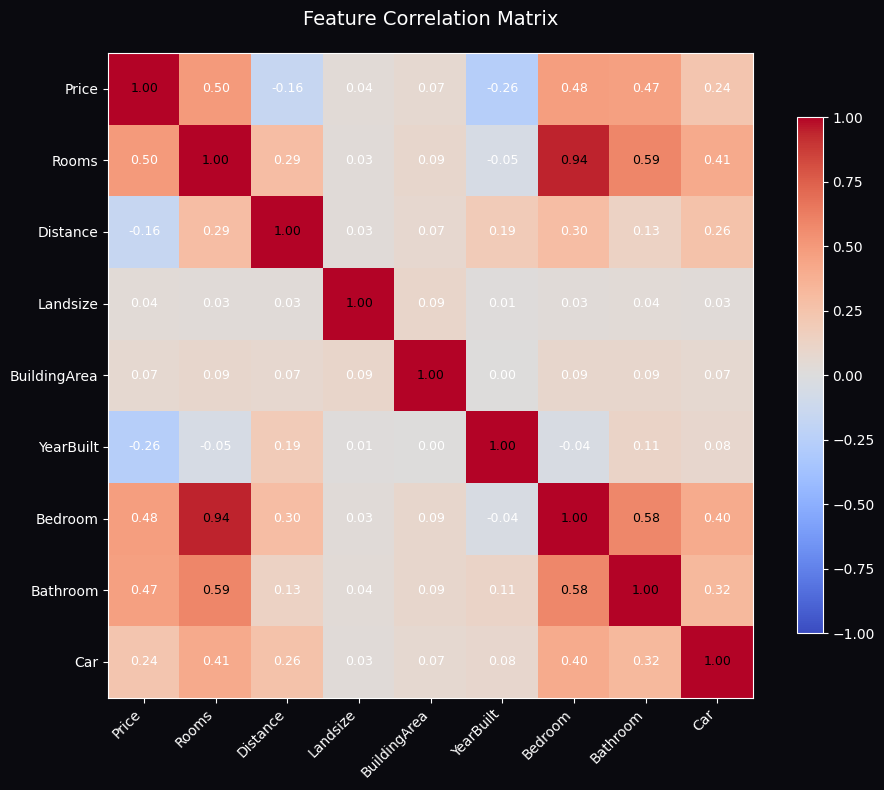


4. AUTOMATED VALUATION MODEL
Training: 10864 samples | Testing: 2716 samples
Tuning Random Forest...

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 15}
Best CV Score (neg MAE): -179762.20

Holdout Performance:
  MAE:   $177,363
  RMSE:  $327,313
  MAPE:  15.9%
  R2:    0.7346

Top 15 Feature Importances:
  Distance                       0.2399  ███████████
  Rooms                          0.1984  █████████
  Postcode                       0.1907  █████████
  Landsize                       0.1082  █████
  Type_u                         0.0838  ████
  BuildingArea                   0.0569  ██
  Bathroom                       0.0345  █
  YearBuilt                      0.0307  █
  Car                            0.0127  
  CouncilArea_Bayside            0.0082  
  CouncilArea_Boroondara         0.0082  
  Bedroom                        0.0067  
  Type_t                         0.0055  
  CouncilArea_Stonnington        0.0037  
  CouncilArea_Moreland           

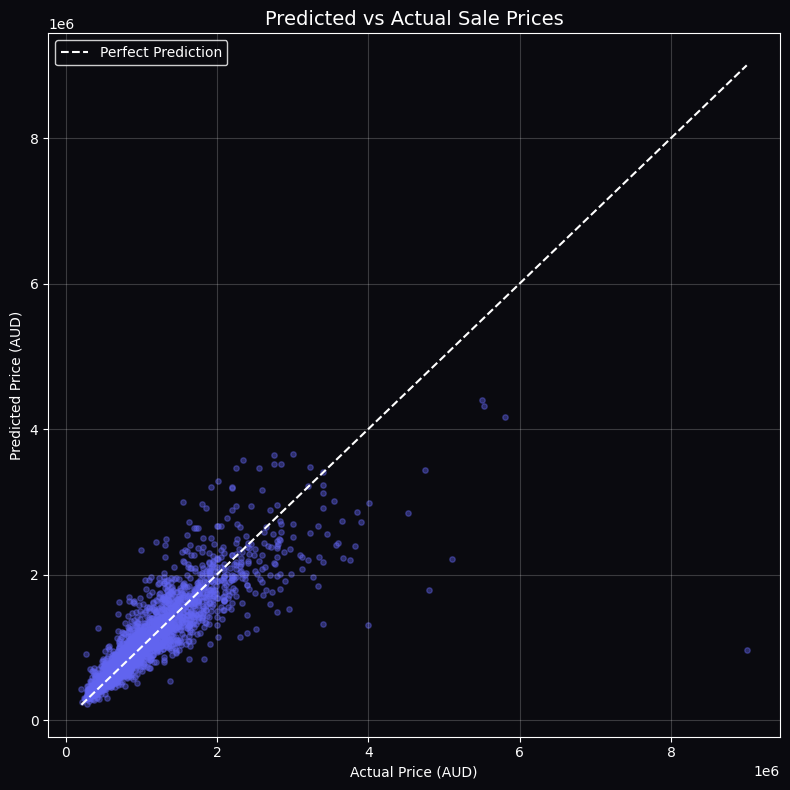


5. SUBURB INVESTMENT SCORING

Top 15 Suburbs by Investment Score:
                 Investment_Score     Investment_Tier
Suburb                                               
Silvan                       52.1  Growth Opportunity
New Gisborne                 39.2          Value Play
Kooyong                      28.7          Value Play
Southbank                    25.9          Value Play
Fitzroy                      24.2         Speculative
Richmond                     23.3         Speculative
North Melbourne              22.9         Speculative
Melbourne                    22.6         Speculative
Collingwood                  22.4         Speculative
Carlton                      22.3         Speculative
South Melbourne              22.0         Speculative
Reservoir                    21.5         Speculative
East Melbourne               21.5         Speculative
Middle Park                  20.9         Speculative
South Yarra                  20.5         Speculative

Tier Distribut

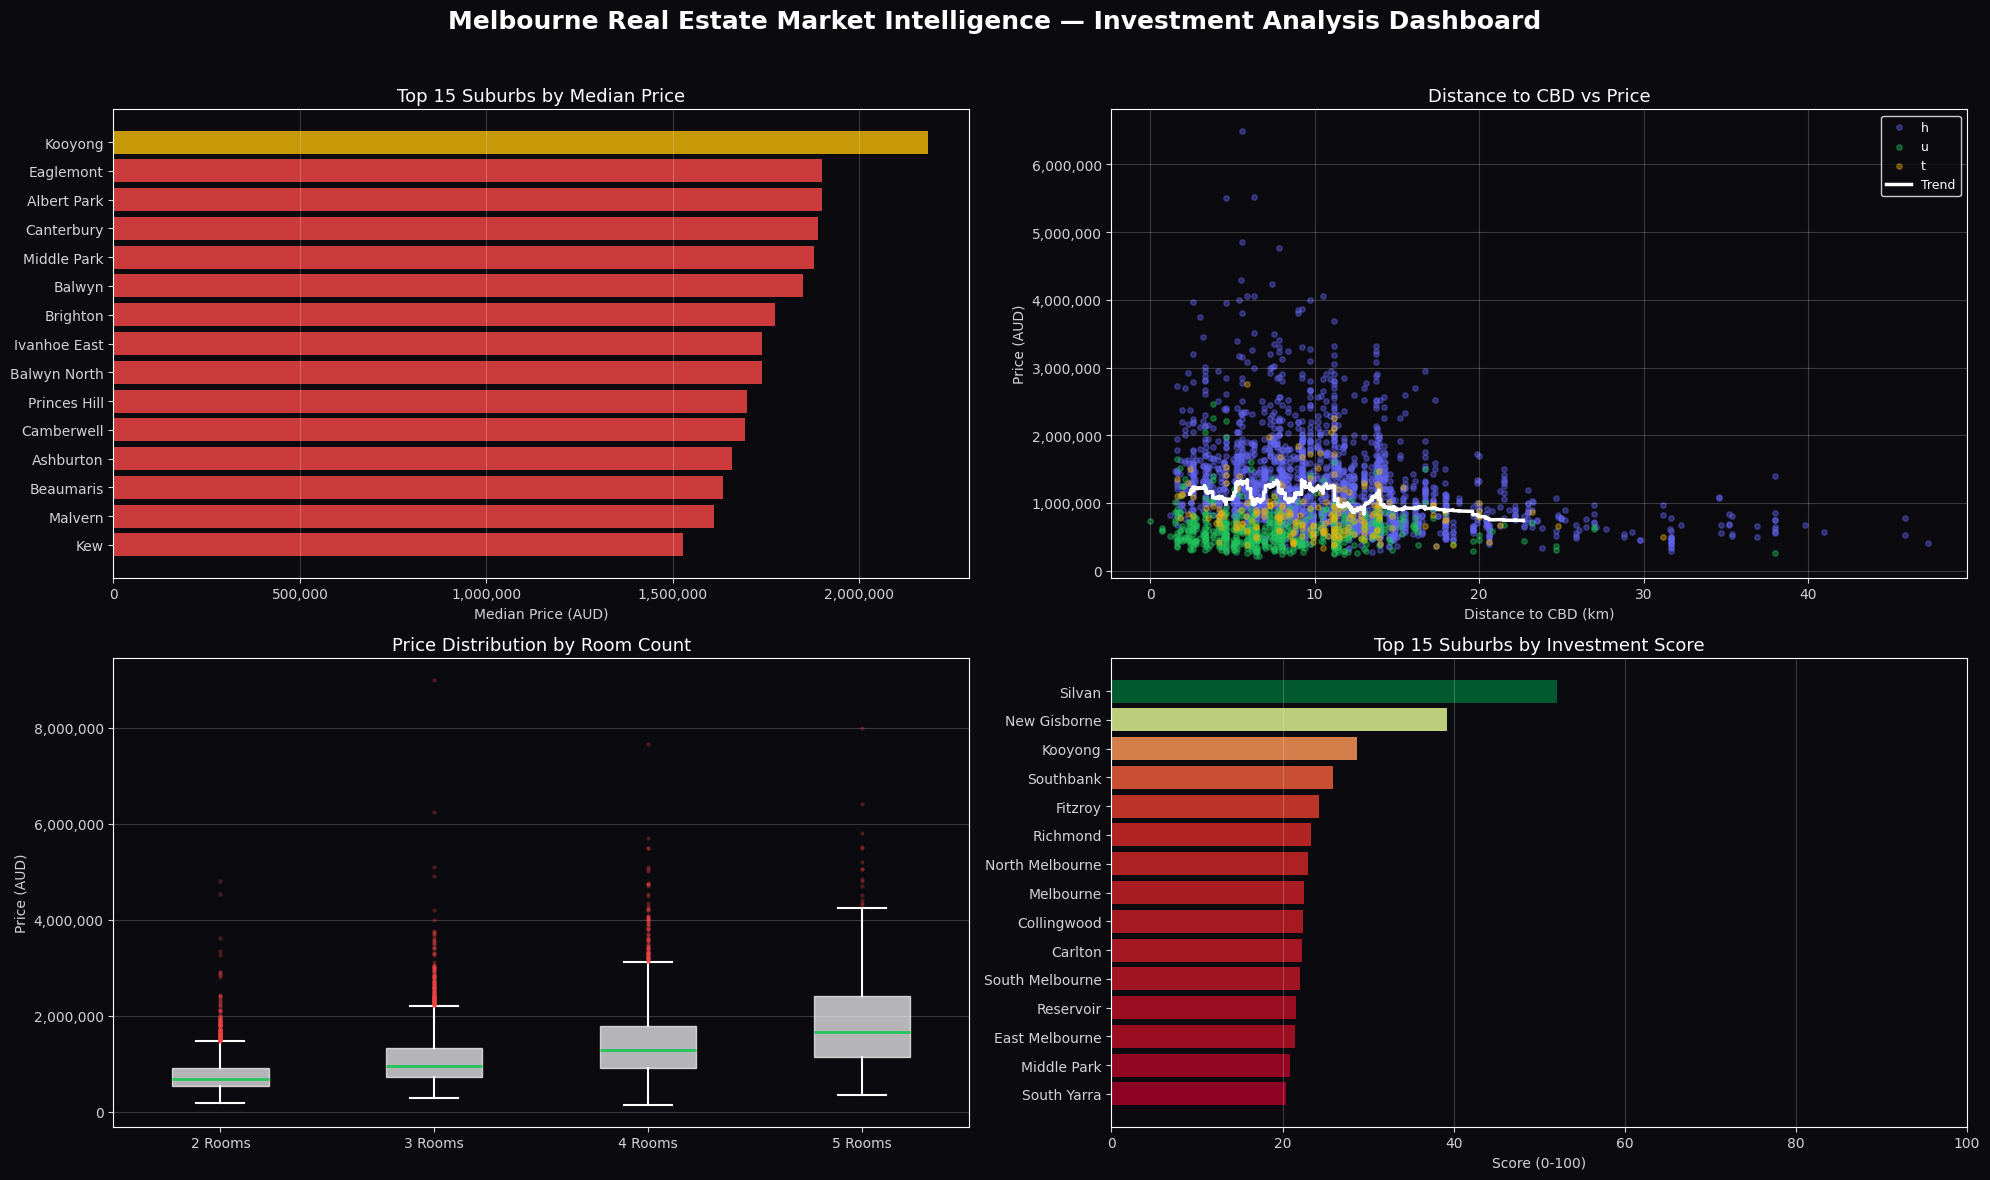


7. PROPERTY LOCATION MAP



8. ANALYTICAL EXPORTS
Exported real_estate_market_data.csv (13,580 rows)
Exported suburb_investment_scores.csv (314 suburbs)

PIPELINE COMPLETE


In [1]:
# ==============================================================================
# REAL ESTATE MARKET INTELLIGENCE TOOL
# Target Audience: Investment Committee
# Purpose: Metropolitan market entry valuation and portfolio allocation strategy
# Data: Melbourne Housing Snapshot (real property transactions)
# ==============================================================================

import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("="*80)
print("1. DATA LOADING AND VALIDATION")
print("="*80)

df_raw = None
dataset_loaded = False

url = "https://raw.githubusercontent.com/plotly/datasets/master/melbourne_housing_snapshot.csv"
try:
    print("Loading Melbourne Housing dataset from public mirror...")
    df_raw = pd.read_csv(url)
    dataset_loaded = True
    print("Successfully loaded from public mirror.")
except Exception as e:
    print(f"Public mirror unavailable: {type(e).__name__}")

if not dataset_loaded:
    try:
        import kagglehub
        path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")
        csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
        if csv_files:
            df_raw = pd.read_csv(os.path.join(path, csv_files[0]))
            dataset_loaded = True
            print(f"Loaded via Kaggle: {csv_files[0]}")
    except Exception as e:
        print(f"Kaggle unavailable: {type(e).__name__}")

if not dataset_loaded:
    if os.path.exists("melbourne_housing.csv"):
        df_raw = pd.read_csv("melbourne_housing.csv")
        dataset_loaded = True
        print("Loaded local file: melbourne_housing.csv")

if not dataset_loaded:
    print("\nDataset could not be loaded automatically.")
    print("Please download from: https://www.kaggle.com/dansbecker/melbourne-housing-snapshot")
    print("Upload as 'melbourne_housing.csv' and re-run.")
    sys.exit()

if 'Bedroom2' in df_raw.columns:
    df_raw.rename(columns={'Bedroom2': 'Bedroom'}, inplace=True)
if 'Lattitude' in df_raw.columns:
    df_raw.rename(columns={'Lattitude': 'Latitude', 'Longtitude': 'Longitude'}, inplace=True)

print(f"\nDataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nFirst 5 rows:")
print(df_raw.head().to_string())

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_report = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
print("\nData Completeness:")
print(missing_report[missing_report['Missing'] > 0].to_string())

# ==============================================================================
# 2. DATA PREPROCESSING AND FEATURE ENGINEERING
# ==============================================================================
print("\n" + "="*80)
print("2. DATA PREPROCESSING AND FEATURE ENGINEERING")
print("="*80)

initial_rows = len(df_raw)
df = df_raw.dropna(subset=['Price']).copy()
print(f"Removed {initial_rows - len(df)} rows with missing Price.")

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year_Sold'] = df['Date'].dt.year
df['Month_Sold'] = df['Date'].dt.month

df['Price_Per_Sqm'] = np.where(df['Landsize'] > 0, df['Price'] / df['Landsize'], np.nan)
df['Price_Per_Sqm'] = df['Price_Per_Sqm'].fillna(df['Price_Per_Sqm'].median())

df['Price_Per_Room'] = np.where(df['Rooms'] > 0, df['Price'] / df['Rooms'], np.nan)
df['Price_Per_Room'] = df['Price_Per_Room'].fillna(df['Price_Per_Room'].median())

print("\nDescriptive Statistics:")
for col in ['Price', 'Landsize', 'BuildingArea', 'Price_Per_Sqm', 'Distance']:
    print(f"  {col}: mean={df[col].mean():,.0f}, median={df[col].median():,.0f}, min={df[col].min():,.0f}, max={df[col].max():,.0f}")

print(f"\nUnique Suburbs: {df['Suburb'].nunique()}")
print(f"Unique Property Types: {df['Type'].nunique()}")
print(f"Unique Council Areas: {df['CouncilArea'].nunique()}")
print(f"Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")

# ==============================================================================
# 3. EXPLORATORY MARKET ANALYSIS
# ==============================================================================
print("\n" + "="*80)
print("3. EXPLORATORY MARKET ANALYSIS")
print("="*80)

suburb_overview = df.groupby('Suburb').agg(
    Transaction_Count=('Price', 'count'),
    Average_Price=('Price', 'mean'),
    Median_Price=('Price', 'median'),
    Average_Price_Per_Sqm=('Price_Per_Sqm', 'mean'),
    Average_Landsize=('Landsize', 'mean'),
    Average_Distance_to_CBD=('Distance', 'mean')
).reset_index().sort_values(by='Average_Price', ascending=False)

print("\nTop 10 Suburbs by Average Price:")
print(suburb_overview.head(10).round(0).to_string(index=False))

prop_type_overview = df.groupby('Type').agg(
    Count=('Price', 'count'),
    Average_Price=('Price', 'mean'),
    Median_Price=('Price', 'median'),
    Average_Rooms=('Rooms', 'mean'),
    Average_Landsize=('Landsize', 'mean')
).reset_index()
print("\nProperty Type Distribution:")
print(prop_type_overview.round(0).to_string(index=False))

corr_features = ['Price', 'Rooms', 'Distance', 'Landsize', 'BuildingArea', 'YearBuilt', 'Bedroom', 'Bathroom', 'Car']
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#0a0a0f')
ax.set_facecolor('#0a0a0f')
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=45, ha='right', color='white')
ax.set_yticklabels(corr_features, color='white')
for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white' if abs(val) < 0.5 else 'black', fontsize=9)
ax.set_title('Feature Correlation Matrix', color='white', pad=20, fontsize=14)
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. AUTOMATED VALUATION MODEL
# ==============================================================================
print("\n" + "="*80)
print("4. AUTOMATED VALUATION MODEL")
print("="*80)

avm_features = ['Rooms', 'Type', 'Distance', 'Postcode', 'Bedroom', 'Bathroom',
                'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea']
X = df[avm_features].copy()
y = df['Price']
X = pd.get_dummies(X, columns=['Type', 'CouncilArea'], drop_first=True)

region_counts = df['Regionname'].value_counts()
valid_regions = region_counts[region_counts > 5].index
df['Stratify_Region'] = df['Regionname'].where(df['Regionname'].isin(valid_regions), 'Other')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=df['Stratify_Region']
)
print(f"Training: {X_train.shape[0]} samples | Testing: {X_test.shape[0]} samples")

print("Tuning Random Forest...")
param_dist = {'n_estimators': [100, 200, 300], 'max_depth': [10, 15, 20, None], 'min_samples_split': [2, 5, 10]}
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
search = RandomizedSearchCV(rf, param_dist, n_iter=5, cv=3, scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
model = search.best_estimator_

print(f"\nBest Parameters: {search.best_params_}")
print(f"Best CV Score (neg MAE): {search.best_score_:.2f}")

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print(f"\nHoldout Performance:")
print(f"  MAE:   ${mae:,.0f}")
print(f"  RMSE:  ${rmse:,.0f}")
print(f"  MAPE:  {mape:.1f}%")
print(f"  R2:    {r2:.4f}")
if r2 > 0.75:
    print("  Model meets R2 target (above 0.75).")

importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
importances = importances.sort_values('Importance', ascending=False).head(15)
print("\nTop 15 Feature Importances:")
for _, row in importances.iterrows():
    bar = chr(9608) * int(row['Importance'] * 50)
    print(f"  {row['Feature']:<30} {row['Importance']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(8, 8), facecolor='#0a0a0f')
ax.set_facecolor('#0a0a0f')
ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='#6366f1')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='white', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Price (AUD)', color='white')
ax.set_ylabel('Predicted Price (AUD)', color='white')
ax.set_title('Predicted vs Actual Sale Prices', color='white', fontsize=14)
ax.legend(facecolor='#0a0a0f', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. SUBURB INVESTMENT SCORING
# ==============================================================================
print("\n" + "="*80)
print("5. SUBURB INVESTMENT SCORING")
print("="*80)

city_median_price_sqm = df['Price_Per_Sqm'].median()
median_year = df['Year_Sold'].median()

recent_sales = df[df['Year_Sold'] >= median_year].groupby('Suburb')['Price'].mean()
older_sales = df[df['Year_Sold'] < median_year].groupby('Suburb')['Price'].mean()
growth_ratio = (recent_sales / older_sales.replace(0, np.nan)).fillna(1.0)

inv_df = df.groupby('Suburb').agg(
    Avg_Distance=('Distance', 'mean'),
    Median_Price_Sqm=('Price_Per_Sqm', 'median'),
    Avg_Landsize=('Landsize', 'mean'),
    Transaction_Count=('Price', 'count')
)
inv_df['Growth_Signal_Ratio'] = growth_ratio
inv_df['Affordability'] = city_median_price_sqm / inv_df['Median_Price_Sqm']
inv_df['Growth_Signal'] = inv_df['Growth_Signal_Ratio']
inv_df['Distance_Advantage'] = 1 / (inv_df['Avg_Distance'] + 0.1)
inv_df['Size_Value'] = inv_df['Avg_Landsize']
inv_df['Liquidity'] = inv_df['Transaction_Count'] / inv_df['Transaction_Count'].max()

components = ['Affordability', 'Growth_Signal', 'Distance_Advantage', 'Size_Value', 'Liquidity']
scaler = MinMaxScaler(feature_range=(0, 100))
inv_df[components] = scaler.fit_transform(inv_df[components])

inv_df['Investment_Score'] = (
    inv_df['Affordability'] * 0.30 +
    inv_df['Growth_Signal'] * 0.25 +
    inv_df['Distance_Advantage'] * 0.20 +
    inv_df['Size_Value'] * 0.15 +
    inv_df['Liquidity'] * 0.10
)

def classify(score):
    if score >= 75: return 'Prime Investment'
    elif score >= 50: return 'Growth Opportunity'
    elif score >= 25: return 'Value Play'
    else: return 'Speculative'

inv_df['Investment_Tier'] = inv_df['Investment_Score'].apply(classify)
inv_df = inv_df.sort_values('Investment_Score', ascending=False)

print("\nTop 15 Suburbs by Investment Score:")
print(inv_df[['Investment_Score', 'Investment_Tier']].head(15).round(1).to_string())
print(f"\nTier Distribution: {inv_df['Investment_Tier'].value_counts().to_dict()}")

# ==============================================================================
# 6. EXECUTIVE DASHBOARD
# ==============================================================================
print("\n" + "="*80)
print("6. EXECUTIVE DASHBOARD")
print("="*80)

tier_colors = {'Prime Investment': '#22c55e', 'Growth Opportunity': '#3b82f6',
               'Value Play': '#eab308', 'Speculative': '#ef4444'}

fig, axes = plt.subplots(2, 2, figsize=(20, 12), facecolor='#0a0a0f')
for ax_row in axes:
    for ax in ax_row:
        ax.set_facecolor('#0a0a0f')

ax1 = axes[0, 0]
top_price = suburb_overview.head(15).sort_values('Median_Price', ascending=True)
colors_p1 = [tier_colors.get(inv_df.loc[s, 'Investment_Tier'], '#6366f1') if s in inv_df.index else '#6366f1' for s in top_price['Suburb']]
ax1.barh(top_price['Suburb'], top_price['Median_Price'], color=colors_p1, alpha=0.85)
ax1.set_title('Top 15 Suburbs by Median Price', color='white', fontsize=13)
ax1.set_xlabel('Median Price (AUD)', color='lightgray')
ax1.tick_params(colors='lightgray')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(axis='x', alpha=0.2)

ax2 = axes[0, 1]
sample_df = df.sample(n=min(3000, len(df)), random_state=42)
for ptype, color in zip(sample_df['Type'].unique(), ['#6366f1', '#22c55e', '#eab308']):
    subset = sample_df[sample_df['Type'] == ptype]
    ax2.scatter(subset['Distance'], subset['Price'], alpha=0.4, label=ptype, color=color, s=15)
sorted_idx = np.argsort(sample_df['Distance'].values)
x_sorted = sample_df['Distance'].values[sorted_idx]
window = 200
y_smooth = pd.Series(sample_df['Price'].values[sorted_idx]).rolling(window=window, center=True).mean()
ax2.plot(x_sorted, y_smooth, color='white', linewidth=2.5, label='Trend')
ax2.set_title('Distance to CBD vs Price', color='white', fontsize=13)
ax2.set_xlabel('Distance to CBD (km)', color='lightgray')
ax2.set_ylabel('Price (AUD)', color='lightgray')
ax2.tick_params(colors='lightgray')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.legend(facecolor='#0a0a0f', edgecolor='white', labelcolor='white', fontsize=9)
ax2.grid(alpha=0.2)

ax3 = axes[1, 0]
rooms_data = [df[df['Rooms'] == r]['Price'].values for r in range(2, 6)]
bp = ax3.boxplot(rooms_data, patch_artist=True, labels=[f'{r} Rooms' for r in range(2, 6)],
                 flierprops=dict(marker='o', markerfacecolor='#ef4444', markersize=3, alpha=0.3, markeredgecolor='none'))
for box in bp['boxes']:
    box.set(facecolor='#3b82f6', color='white', alpha=0.7)
for whisker in bp['whiskers']: whisker.set(color='white', linewidth=1.5)
for cap in bp['caps']: cap.set(color='white', linewidth=1.5)
for median in bp['medians']: median.set(color='#22c55e', linewidth=2)
ax3.set_title('Price Distribution by Room Count', color='white', fontsize=13)
ax3.set_ylabel('Price (AUD)', color='lightgray')
ax3.tick_params(colors='lightgray')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax3.grid(axis='y', alpha=0.2)

ax4 = axes[1, 1]
top_scores = inv_df.head(15).sort_values('Investment_Score', ascending=True)
norm = plt.Normalize(top_scores['Investment_Score'].min(), top_scores['Investment_Score'].max())
cmap = plt.cm.RdYlGn
colors_p4 = cmap(norm(top_scores['Investment_Score'].values))
ax4.barh(top_scores.index, top_scores['Investment_Score'], color=colors_p4, alpha=0.85)
ax4.set_title('Top 15 Suburbs by Investment Score', color='white', fontsize=13)
ax4.set_xlabel('Score (0-100)', color='lightgray')
ax4.tick_params(colors='lightgray')
ax4.grid(axis='x', alpha=0.2)
ax4.set_xlim(0, 100)

fig.suptitle('Melbourne Real Estate Market Intelligence — Investment Analysis Dashboard', color='white', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ==============================================================================
# 7. PROPERTY LOCATION MAP
# ==============================================================================
print("\n" + "="*80)
print("7. PROPERTY LOCATION MAP")
print("="*80)

if 'Latitude' in df.columns and 'Longitude' in df.columns:
    df_map = df.dropna(subset=['Latitude', 'Longitude']).copy()
    df_map['Map_Bubble_Size'] = df_map['Landsize'].clip(lower=50, upper=1000)
    if len(df_map) > 5000:
        df_map = df_map.sample(5000, random_state=42)

    fig_map = px.scatter_mapbox(
        df_map, lat="Latitude", lon="Longitude", color="Price_Per_Sqm",
        size="Map_Bubble_Size", color_continuous_scale=px.colors.sequential.Viridis,
        size_max=15, zoom=10, mapbox_style="carto-darkmatter",
        hover_name="Suburb",
        hover_data={"Price": ":$,.0f", "Rooms": True, "Type": True, "Landsize": True, "Price_Per_Sqm": ":$,.0f"},
        title="Melbourne Property Market — Price per Square Meter and Land Size"
    )
    fig_map.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, paper_bgcolor="#0a0a0f", font_color="white")
    fig_map.show()
else:
    print("Location coordinates not available in this dataset.")

# ==============================================================================
# 8. ANALYTICAL EXPORTS
# ==============================================================================
print("\n" + "="*80)
print("8. ANALYTICAL EXPORTS")
print("="*80)

df.to_csv("real_estate_market_data.csv", index=False)
inv_df.to_csv("suburb_investment_scores.csv")
print(f"Exported real_estate_market_data.csv ({len(df):,} rows)")
print(f"Exported suburb_investment_scores.csv ({len(inv_df)} suburbs)")
print("\nPIPELINE COMPLETE")